<a href="https://colab.research.google.com/github/ANANYA-JPG/data-mining-and-ML/blob/main/Simulating%20the%20Time-Dependent%20Schroedinger%20Equation%20on%20a%20Quantum%20Computer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulating the Time-Dependent Schroedinger Equation on a Quantum Computer** by Ananya Haldankar, Prince Perera, and Vijayalakshmi Sivaraman

Install all necessary packages and import the relevant header files.

In [ ]:
!pip install qiskit-aer --upgrade
!pip install qiskit matplotlib pylatexenc --upgrade

import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 36.7 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=ddcf95eab1f6fe7bd6e5040a6350184276c2b876c702160f89235d9f23727e35
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c

Constants and functions used to build and display the circuit:

In [ ]:
n_qubits = 3
n_sites = 2**n_qubits
phi_example = np.pi / 4
L = 1.0
delta_x = L / n_sites
delta_t = 0.1
hbar = 1.0
m = 1.0
phi_vals = np.linspace(0, np.pi, 5)

def build_qft_circuit(n_qubits):
    qc = QuantumCircuit(n_qubits, name="QFT")
    for j in range(n_qubits):
        for k in range(j):
            qc.cp(np.pi / 2**(j-k), k, j)
        qc.h(j)
    return qc

def build_momentum_phase_circuit(phi, n_qubits):
    qc = QuantumCircuit(n_qubits, name="Momentum Phase")
    for qubit in range(n_qubits):
        qc.p(phi / (2**qubit), qubit)
    return qc

def build_potential_operator_circuit(phi, n_qubits):
    qc = QuantumCircuit(n_qubits, name="Potential Operator")

    for i in range(n_qubits):
        theta = phi / (2**i)
        qc.p(theta, i)
    qc.barrier()
    return qc

def display_partial_circuit(title, circuit):
    print(f"\n--- {title} ---")
    circuit.draw(output='mpl', style={
        'name': 'iqp',
        'gate_facecolor': '#FF6666',
        'linecolor': '#0040FF',
        'fontsize': 12
    }, filename='circuit.png')

    img = plt.imread('circuit.png')
    plt.imshow(img)
    plt.axis('off')
    plt.show()


Building the circuit:


--- Step 1: Quantum Fourier Transform ---


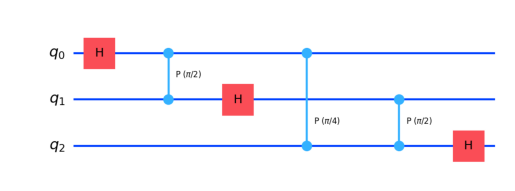

In [ ]:
qft_circuit = build_qft_circuit(n_qubits)
display_partial_circuit("Step 1: Quantum Fourier Transform", qft_circuit)


--- Step 2: Pauli-X Gate for Re-centering ---


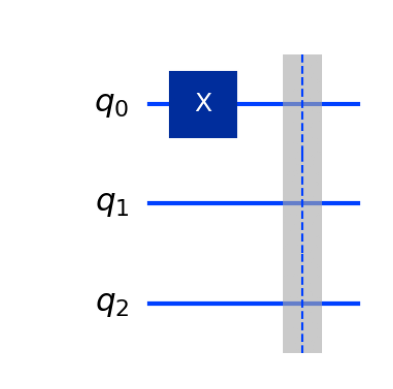

In [ ]:
pauli_x_recenter = QuantumCircuit(n_qubits, name="Pauli-X Re-center")
pauli_x_recenter.x(0)
pauli_x_recenter.barrier()
display_partial_circuit("Step 2: Pauli-X Gate for Re-centering", pauli_x_recenter)


--- Step 3: Momentum Phase Operator ---


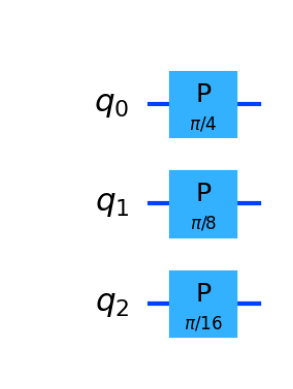

In [ ]:
momentum_phase_circuit = build_momentum_phase_circuit(phi_example, n_qubits)
display_partial_circuit("Step 3: Momentum Phase Operator", momentum_phase_circuit)


--- Step 3: Momentum Phase Operator ---


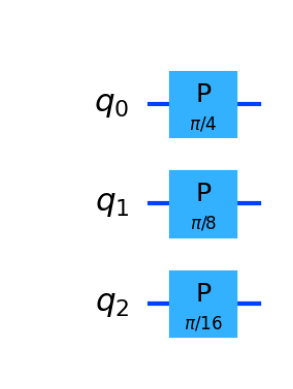

In [ ]:
momentum_phase_circuit = build_momentum_phase_circuit(phi_example, n_qubits)
display_partial_circuit("Step 3: Momentum Phase Operator", momentum_phase_circuit)


--- Step 4: Potential Operator ---


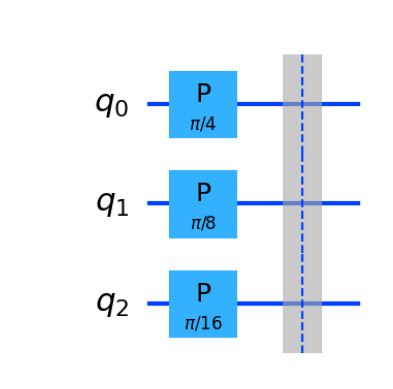

In [ ]:
potential_operator_circuit = build_potential_operator_circuit(phi_example, n_qubits)
display_partial_circuit("Step 4: Potential Operator", potential_operator_circuit)


--- Step 5: Pauli-X Gate for De-centering ---


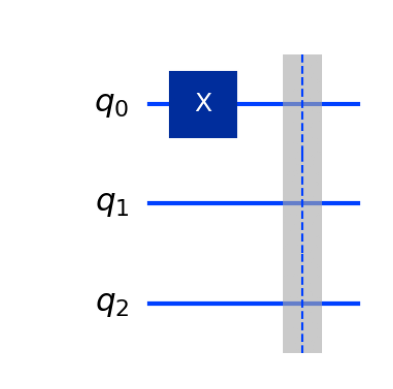

In [ ]:
pauli_x_decenter = QuantumCircuit(n_qubits, name="Pauli-X De-center")
pauli_x_decenter.x(0)
pauli_x_decenter.barrier()
display_partial_circuit("Step 5: Pauli-X Gate for De-centering", pauli_x_decenter)


--- Step 6: Inverse Quantum Fourier Transform ---


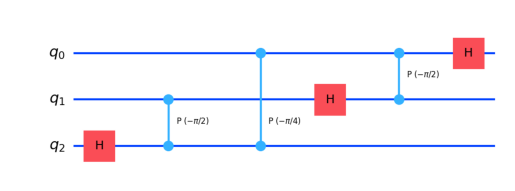

In [ ]:
iqft_circuit = build_qft_circuit(n_qubits).inverse()
display_partial_circuit("Step 6: Inverse Quantum Fourier Transform", iqft_circuit)


--- Full Time Evolution Quantum Circuit ---


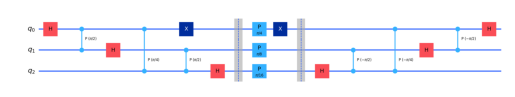

In [ ]:
full_circuit = QuantumCircuit(n_qubits)
full_circuit.compose(qft_circuit, inplace=True)
full_circuit.compose(pauli_x_recenter, inplace=True)
full_circuit.compose(momentum_phase_circuit, inplace=True)
full_circuit.compose(pauli_x_decenter, inplace=True)
full_circuit.compose(iqft_circuit, inplace=True)
display_partial_circuit("Full Time Evolution Quantum Circuit", full_circuit)

Building the simulation for the Quantum circuit according to the given initial conditions:


--- Free Particle ---


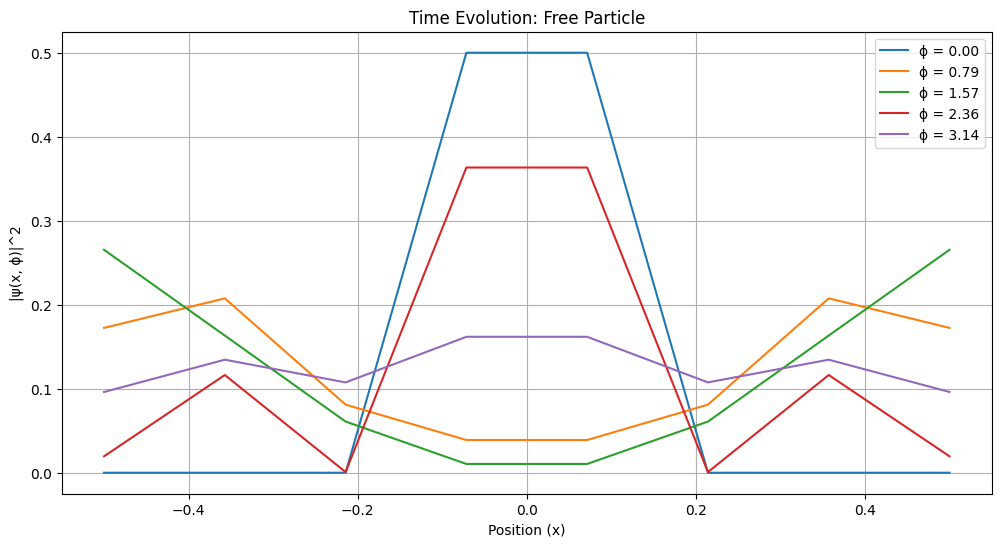

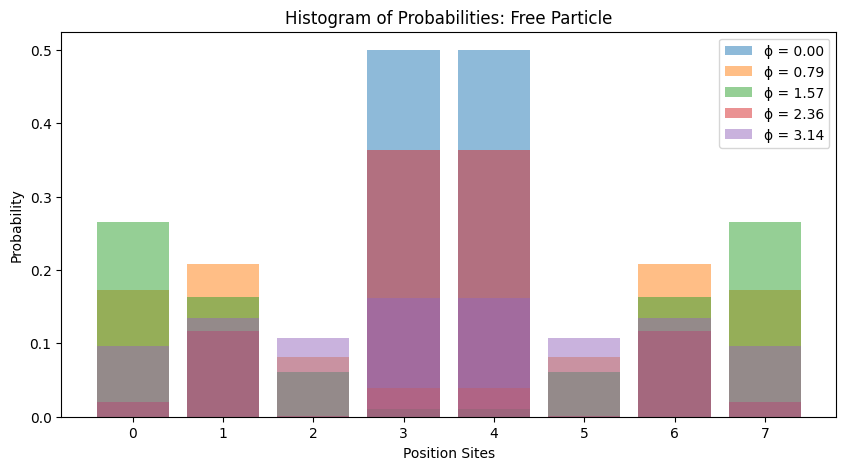


--- With Potential ---


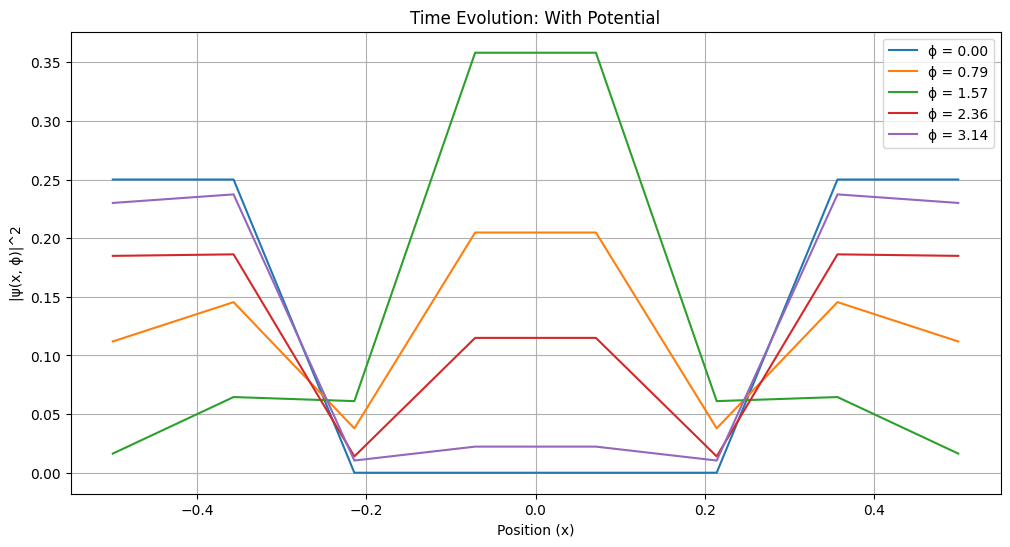

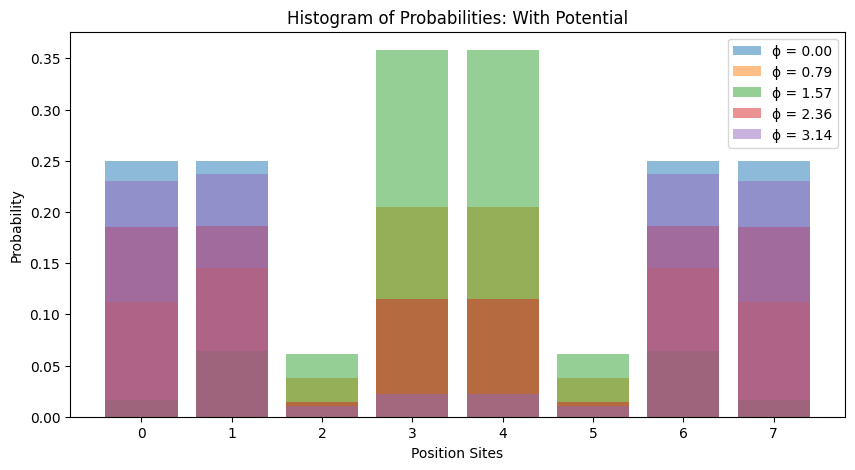

In [ ]:
initial_conditions = {
    "Free Particle": np.array([0, 0, 0, 1/np.sqrt(2), 1/np.sqrt(2), 0, 0, 0], dtype=complex),
    "With Potential": np.array([1/2, 1/2, 0, 0, 0, 0, 1/2, 1/2], dtype=complex)
}

def qft(psi): return fft(psi)
def iqft(psi): return ifft(psi)

def momentum_phase(psi_p, phi):
    p = np.arange(-n_sites//2, n_sites//2) * (2 * np.pi / L)
    return np.exp(-1j * hbar * phi * p**2 / (2 * m)) * psi_p

def position_phase(psi_x, phi):
    x = np.linspace(-L/2, L/2, n_sites)
    V_x = hbar * phi * x / delta_x
    return np.exp(-1j * V_x * delta_t / hbar) * psi_x

def simulate(psi_x, with_potential=False):
    probabilities = []
    for phi in phi_vals:
        psi_p = qft(psi_x)
        psi_p = momentum_phase(psi_p, phi)
        psi_x_free = iqft(psi_p)
        if with_potential:
            psi_x_free = position_phase(psi_x_free, phi)
        probabilities.append(np.abs(psi_x_free)**2)
    return probabilities


def plot_results(psi_x, title, with_potential=False):
    probabilities = simulate(psi_x, with_potential)
    x_coords = np.linspace(-L/2, L/2, n_sites)
    plt.figure(figsize=(12, 6))
    for i, phi in enumerate(phi_vals):
        plt.plot(x_coords, probabilities[i], label=f'ϕ = {phi:.2f}')
    plt.xlabel('Position (x)')
    plt.ylabel('|ψ(x, ϕ)|^2')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()
    return probabilities

def plot_histogram(probabilities, title):
    plt.figure(figsize=(10, 5))
    for i, phi in enumerate(phi_vals):
        plt.bar(range(n_sites), probabilities[i], alpha=0.5, label=f'ϕ = {phi:.2f}')
    plt.xlabel('Position Sites')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    plt.show()


for label, psi_x in initial_conditions.items():
    print(f"\n--- {label} ---")
    probabilities = plot_results(psi_x, f'Time Evolution: {label}', with_potential=(label == "With Potential"))
    plot_histogram(probabilities, f'Histogram of Probabilities: {label}')



--- Step 1: State Preparation ---


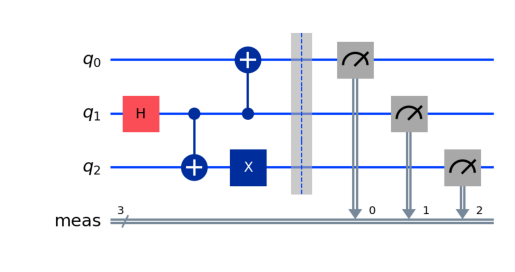


--- Step 2: Quantum Fourier Transform ---


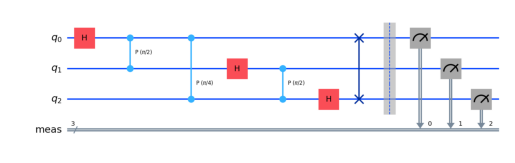


--- Step 3: Momentum Phase Operator ---


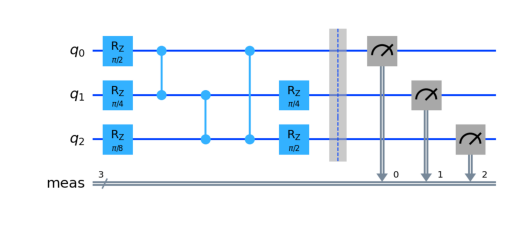


--- Step 4: Potential Operator ---


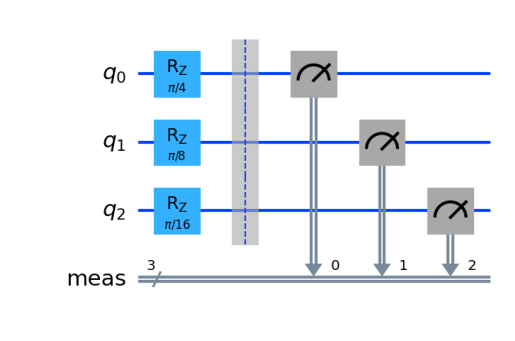


--- Step 5: Pauli-X Recenter Gate ---


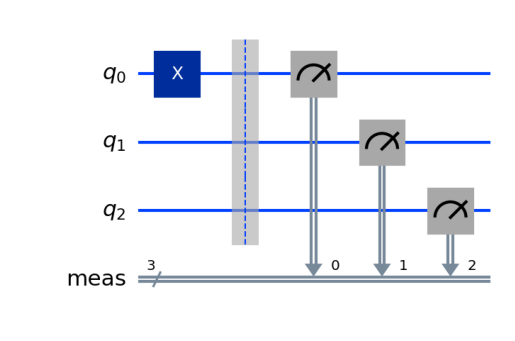


--- Step 6: Controlled Gate Sequence ---


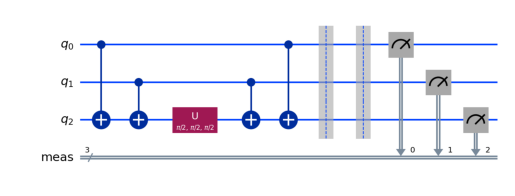


--- Step 7: Inverse Quantum Fourier Transform ---


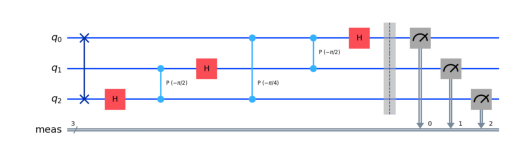


--- Step 8: Pauli-X Decenter Gate ---


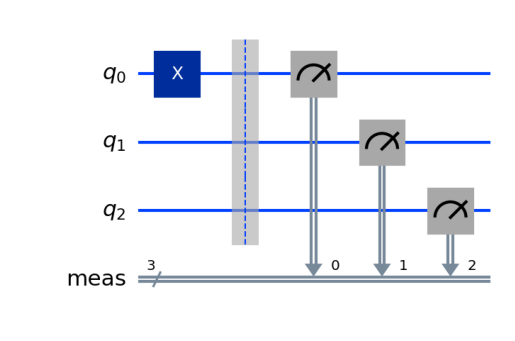


--- Step 9: Four-Qubit Operator ---


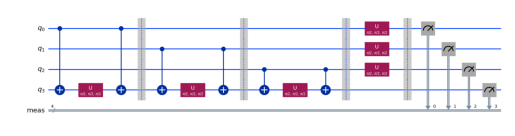


--- Step 10: Full Time Evolution ---


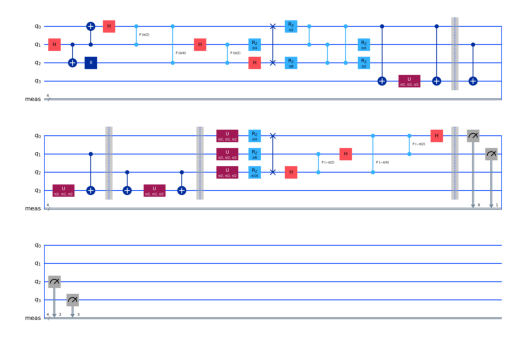


--- Free ---


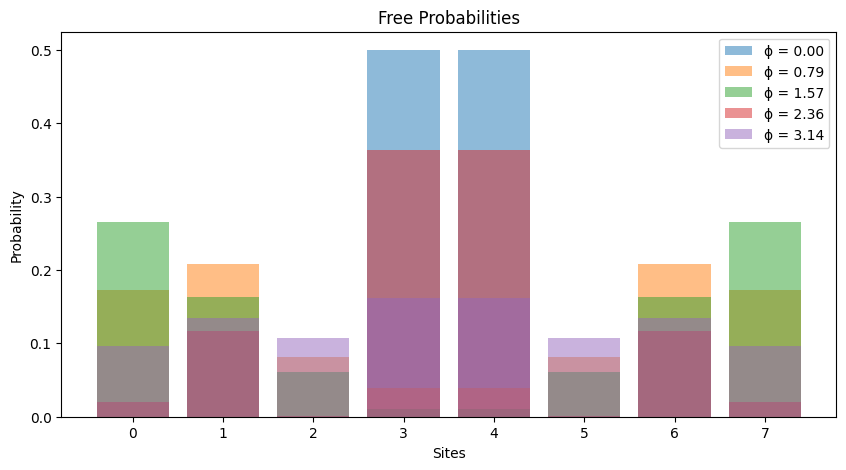


--- Potential ---


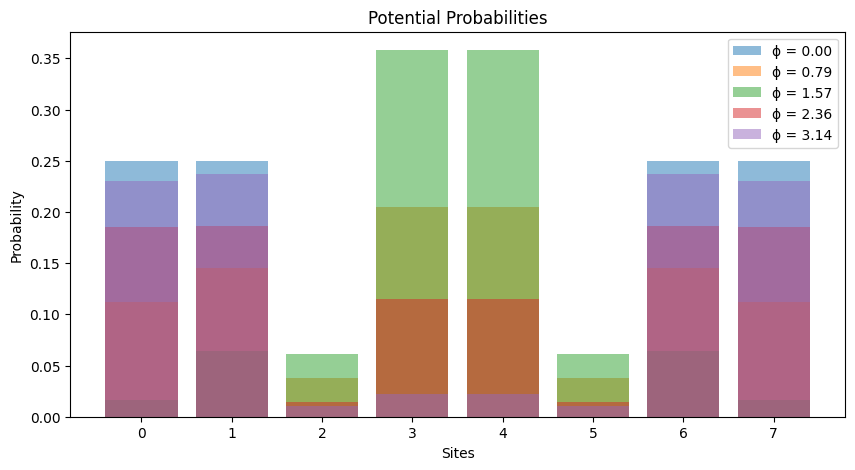

In [ ]:
# !pip install qiskit-aer --upgrade
# !pip install qiskit matplotlib pylatexenc --upgrade

import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

n_qubits = 3
n_sites = 2**n_qubits
phi = np.pi / 4
L = 1.0
dx = L / n_sites
dt = 0.1
hbar = 1.0
m = 1.0
phi_vals = np.linspace(0, np.pi, 5)

def state_preparation():
    qc = QuantumCircuit(3, name="StatePreparation")
    qc.h(1)
    qc.cx(1, 2)
    qc.cx(1, 0)
    qc.x(2)
    return qc

def quantum_fourier_transform():
    qc = QuantumCircuit(3, name="QFT")
    qc.h(0)
    qc.cp(np.pi/2, 0, 1)
    qc.cp(np.pi/4, 0, 2)
    qc.h(1)
    qc.cp(np.pi/2, 1, 2)
    qc.h(2)
    qc.swap(0, 2)
    return qc

def inverse_quantum_fourier_transform():
    qc = QuantumCircuit(3, name="InverseQFT")
    qc.swap(0, 2)
    qc.h(2)
    qc.cp(-np.pi/2, 1, 2)
    qc.h(1)
    qc.cp(-np.pi/4, 0, 2)
    qc.cp(-np.pi/2, 0, 1)
    qc.h(0)
    return qc

def momentum_phase_operator(phi):
    qc = QuantumCircuit(3, name="MomentumPhase")
    qc.rz(2 * phi, 0)
    qc.rz(phi, 1)
    qc.rz(phi / 2, 2)
    qc.cz(0, 1)
    qc.cz(1, 2)
    qc.cz(0, 2)
    qc.rz(phi, 1)
    qc.rz(2 * phi, 2)
    return qc

def potential_operator(phi):
    qc = QuantumCircuit(3, name="PotentialOperator")
    qc.rz(phi, 0)
    qc.rz(phi / 2, 1)
    qc.rz(phi / 4, 2)
    return qc

def pauli_x_gate(name):
    qc = QuantumCircuit(3, name=name)
    qc.x(0)
    return qc

def controlled_gate_sequence():
    qc = QuantumCircuit(3, name="ControlledGateSequence")
    qc.cx(0, 2)
    qc.cx(1, 2)
    qc.u(np.pi/2, np.pi/2, np.pi/2, 2)
    qc.cx(1, 2)
    qc.cx(0, 2)
    qc.barrier()
    return qc

def four_qubit_operator():
    qc = QuantumCircuit(4, name="FourQubitOperator")
    for i, j in [(0, 3), (1, 3), (2, 3)]:
        qc.cx(i, j)
        qc.u(np.pi/2, np.pi/2, np.pi/2, 3)
        qc.cx(i, j)
        qc.barrier()
    for i in range(3):
        qc.u(np.pi/2, np.pi/2, np.pi/2, i)
    return qc

def display_circuit(title, circuit):
    print(f"\n--- {title} ---")
    circuit.measure_all()
    circuit.draw(output='mpl', style={
        'name': 'iqp',
        'gate_facecolor': '#FF6666',
        'linecolor': '#0040FF',
        'fontsize': 12
    }, filename='circuit.png')
    img = plt.imread('circuit.png')
    plt.imshow(img)
    plt.axis('off')
    plt.show()

state_circ = state_preparation()
display_circuit("Step 1: State Preparation", state_circ)

qft_circ = quantum_fourier_transform()
display_circuit("Step 2: Quantum Fourier Transform", qft_circ)

momentum_circ = momentum_phase_operator(phi)
display_circuit("Step 3: Momentum Phase Operator", momentum_circ)

potential_circ = potential_operator(phi)
display_circuit("Step 4: Potential Operator", potential_circ)

recenter_circ = pauli_x_gate("RecenterGate")
display_circuit("Step 5: Pauli-X Recenter Gate", recenter_circ)

controlled_circ = controlled_gate_sequence()
display_circuit("Step 6: Controlled Gate Sequence", controlled_circ)

inverse_qft_circ = inverse_quantum_fourier_transform()
display_circuit("Step 7: Inverse Quantum Fourier Transform", inverse_qft_circ)

decenter_circ = pauli_x_gate("DecenterGate")
display_circuit("Step 8: Pauli-X Decenter Gate", decenter_circ)

four_qubit_circ = four_qubit_operator()
display_circuit("Step 9: Four-Qubit Operator", four_qubit_circ)

full_circuit = QuantumCircuit(4, name="FullTimeEvolution")
full_circuit.compose(state_preparation(), qubits=[0, 1, 2], inplace=True)
full_circuit.compose(quantum_fourier_transform(), qubits=[0, 1, 2], inplace=True)
full_circuit.compose(momentum_phase_operator(phi), qubits=[0, 1, 2], inplace=True)
full_circuit.compose(four_qubit_operator(), inplace=True)
full_circuit.compose(potential_operator(phi), qubits=[0, 1, 2], inplace=True)
full_circuit.compose(inverse_quantum_fourier_transform(), qubits=[0, 1, 2], inplace=True)
display_circuit("Step 10: Full Time Evolution", full_circuit)

initial_conditions = {
    "Free": np.array([0, 0, 0, 1/np.sqrt(2), 1/np.sqrt(2), 0, 0, 0], dtype=complex),
    "Potential": np.array([1/2, 1/2, 0, 0, 0, 0, 1/2, 1/2], dtype=complex)
}

def quantum_fft(psi): return fft(psi)
def inverse_fft(psi): return ifft(psi)

def momentum_transform(psi_p, phi):
    p = np.arange(-n_sites//2, n_sites//2) * (2 * np.pi / L)
    return np.exp(-1j * hbar * phi * p**2 / (2 * m)) * psi_p

def position_transform(psi_x, phi):
    x = np.linspace(-L/2, L/2, n_sites)
    V = hbar * phi * x / dx
    return np.exp(-1j * V * dt / hbar) * psi_x

def simulate(psi_x, potential=False):
    probs = []
    for phi in phi_vals:
        psi_p = quantum_fft(psi_x)
        psi_p = momentum_transform(psi_p, phi)
        psi_x_free = inverse_fft(psi_p)
        if potential:
            psi_x_free = position_transform(psi_x_free, phi)
        probs.append(np.abs(psi_x_free)**2)
    return probs

def plot_results(psi_x, title, potential=False):
    probs = simulate(psi_x, potential)
    x_coords = np.linspace(-L/2, L/2, n_sites)
    plt.figure(figsize=(12, 6))
    for i, phi in enumerate(phi_vals):
        plt.plot(x_coords, probs[i], label=f'ϕ = {phi:.2f}')
    plt.xlabel('x')
    plt.ylabel('|ψ(x, ϕ)|^2')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

def plot_histogram(probs, title):
    plt.figure(figsize=(10, 5))
    for i, phi in enumerate(phi_vals):
        plt.bar(range(n_sites), probs[i], alpha=0.5, label=f'ϕ = {phi:.2f}')
    plt.xlabel('Sites')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    plt.show()

for label, psi_x in initial_conditions.items():
    print(f"\n--- {label} ---")
    probs = simulate(psi_x, potential=(label == "Potential"))
    plot_histogram(probs, f'{label} Probabilities')
